# Analisis de residuos

## Librerias 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf as acf_values
from statsmodels.tsa.stattools import bds as bds_test
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
 
# ── Colores consistentes con notebook 2 ───────────────────────────────────────
COLOR_PRICE  = "#378ADD"
COLOR_POS    = "#1D9E75"
COLOR_NEG    = "#E24B4A"
COLOR_HIST   = "#7F77DD"
COLOR_VOL    = "#5DCAA5"
COLOR_VOLA   = "#D85A30"
COLOR_ACF_SQ = "#BA7517"

In [3]:
DIR_MODELS  = "models"
DIR_FIGS    = os.path.join("notebooks", "figs")
DIR_RESULTS = "results"
os.makedirs(DIR_FIGS,    exist_ok=True)
os.makedirs(DIR_RESULTS, exist_ok=True)

In [4]:
def save_fig(name):
    path = os.path.join(DIR_FIGS, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  → Figura guardada: {path}")
 
def save_csv(df, name):
    path = os.path.join(DIR_RESULTS, name)
    df.to_csv(path, index=False)
    print(f"  → CSV guardado: {path}")

## Carga de residuos

In [5]:
print("Cargando resultados del notebook 2...\n")
 
# results_lags contiene todo: predicciones, residuos, métricas, índices
results_lags  = joblib.load(os.path.join(DIR_MODELS, "results_lags.pkl"))
pipeline_meta = joblib.load(os.path.join(DIR_MODELS, "pipeline_meta.pkl"))
 
LAGS_LIST        = pipeline_meta["LAGS_LIST"]
N_STEPS_FORECAST = pipeline_meta["N_STEPS_FORECAST"]
horizons         = list(range(1, N_STEPS_FORECAST + 1))
 
print(f"Lags disponibles     : {LAGS_LIST}")
print(f"Horizontes           : h=1..{N_STEPS_FORECAST}")
print(f"Mejor lag (RMSE)     : {pipeline_meta['best_lag']} minutos")
print(f"Mejor arq por lag    : {pipeline_meta['best_arch_per_lag']}")


Cargando resultados del notebook 2...

Lags disponibles     : [15, 30, 60, 90]
Horizontes           : h=1..7
Mejor lag (RMSE)     : 30 minutos
Mejor arq por lag    : {15: {'arch': (32, 64), 'dmask': (False, False)}, 30: {'arch': (32, 64), 'dmask': (False, False)}, 60: {'arch': (32, 128), 'dmask': (False, False)}, 90: {'arch': (32, 128), 'dmask': (False, False)}}


In [6]:
# Verificar que los residuos están disponibles
for n in LAGS_LIST:
    r = results_lags[n]
    n_folds = len(r["resid_h1_folds"])
    shapes  = [r["resid_h1_folds"][f].shape for f in range(n_folds)]
    print(f"  Lag {n:>2}min — {n_folds} folds | shapes residuos h1: {shapes}")

  Lag 15min — 5 folds | shapes residuos h1: [(33545,), (33545,), (33545,), (33545,), (33545,)]
  Lag 30min — 5 folds | shapes residuos h1: [(17137,), (17137,), (17137,), (17137,), (17137,)]
  Lag 60min — 5 folds | shapes residuos h1: [(8662,), (8662,), (8662,), (8662,), (8663,)]
  Lag 90min — 5 folds | shapes residuos h1: [(5796,), (5796,), (5796,), (5796,), (5796,)]


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Función BDS robusta (misma que notebook 2)
# ─────────────────────────────────────────────────────────────────────────────
def _bds_pval(resid):
    """Calcula el p-value BDS sobre un array de residuos."""
    if np.isnan(resid).any() or resid.std() < 1e-10 or len(resid) < 50:
        return np.nan
    try:
        bds_res = bds_test(resid, max_dim=2)
        if hasattr(bds_res, "pvalue"):
            raw = bds_res.pvalue
            return float(raw[1]) if hasattr(raw, "__len__") and len(raw) > 1 else float(raw)
        elif hasattr(bds_res, "iloc"):
            return float(bds_res.iloc[1]["p-value"])
        else:
            return float(bds_res[1])
    except Exception as e:
        print(f"    ⚠️  BDS error: {type(e).__name__}: {e}")
        return np.nan
 
def _bds_avg(resid_folds):
    """BDS promedio sobre todos los folds de un lag."""
    pvals = [_bds_pval(r) for r in resid_folds]
    return np.nanmean(pvals)

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — Tabla BDS completa por lag y fold
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("BDS TEST — RESIDUOS h=1 | Por lag y fold")
print("H0: residuos i.i.d. | p > 0.05 → no rechazo | p < 0.05 → rechazo ")
print("="*70)
 
bds_summary = []
for n in LAGS_LIST:
    r           = results_lags[n]
    resid_folds = r["resid_h1_folds"]
    n_folds     = len(resid_folds)
    pvals       = [_bds_pval(resid_folds[f]) for f in range(n_folds)]
 
    row = {"Lag (min)": n}
    for f, pv in enumerate(pvals):
        row[f"Fold {f+1}"] = f"{pv:.4f}" if not np.isnan(pv) else "nan"
 
    avg = np.nanmean(pvals)
    std = np.nanstd(pvals)
    interp_avg = " no rechazo iid" if avg > 0.05 else "estructura remanente"
    row["Mean ± Std"] = f"{avg:.4f} ± {std:.4f}"
    row["Conclusión"] = interp_avg
    bds_summary.append(row)
 
df_bds = pd.DataFrame(bds_summary).set_index("Lag (min)")
print(df_bds.to_string())
save_csv(df_bds.reset_index(), "bds_summary_por_lag.csv")


BDS TEST — RESIDUOS h=1 | Por lag y fold
H0: residuos i.i.d. | p > 0.05 → no rechazo | p < 0.05 → rechazo 
           Fold 1  Fold 2  Fold 3  Fold 4  Fold 5       Mean ± Std            Conclusión
Lag (min)                                                                               
15         0.0995  0.0559  0.0674  0.0000  0.0000  0.0446 ± 0.0391  estructura remanente
30         0.0924  0.1795  0.1110  0.0771  0.3658  0.1651 ± 0.1063        no rechazo iid
60         0.4854  0.4856  0.4750  0.1784  0.5685  0.4386 ± 0.1344        no rechazo iid
90         0.5774  0.7769  0.7702  0.6877  0.3637  0.6352 ± 0.1537        no rechazo iid
  → CSV guardado: results\bds_summary_por_lag.csv


  → Figura guardada: notebooks\figs\residuos_distribucion_h1_por_lag.png


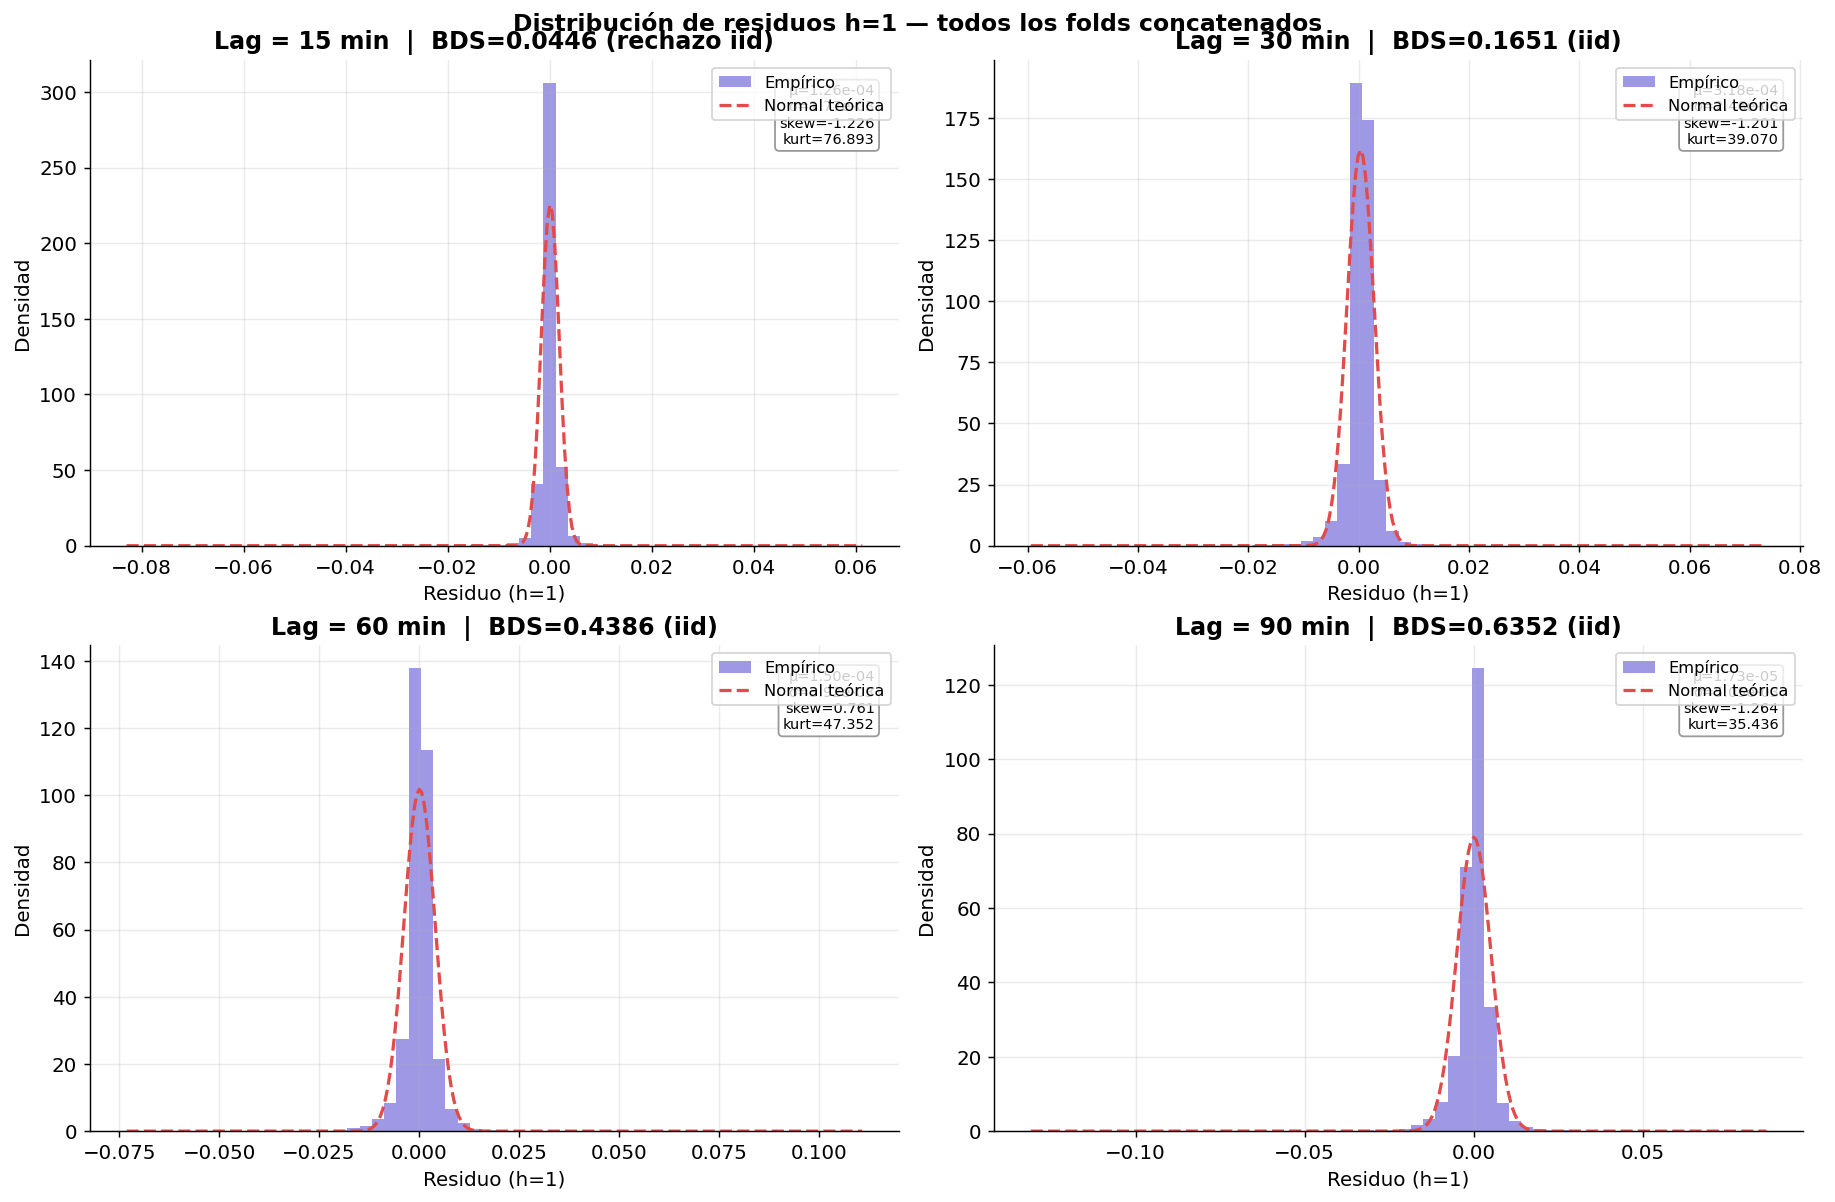

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — Distribución de residuos por lag (h=1)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
axes = axes.flatten()
 
for i, n in enumerate(LAGS_LIST):
    ax          = axes[i]
    resid_folds = results_lags[n]["resid_h1_folds"]
    n_folds     = len(resid_folds)
 
    # Concatenar residuos de todos los folds
    all_resid = np.concatenate(resid_folds)
 
    # Histograma
    ax.hist(all_resid, bins=60, density=True,
            color=COLOR_HIST, alpha=0.75, edgecolor="none",
            label="Empírico")
 
    # Curva normal teórica
    mu, sigma = all_resid.mean(), all_resid.std()
    x = np.linspace(all_resid.min(), all_resid.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color=COLOR_NEG, linewidth=1.8, linestyle="--",
            label="Normal teórica")
 
    # Estadísticas en el plot
    skew = stats.skew(all_resid)
    kurt = stats.kurtosis(all_resid)
    bds_avg = _bds_avg(resid_folds)
    interp  = "iid" if bds_avg > 0.05 else "rechazo iid"
 
    ax.set_title(f"Lag = {n} min  |  BDS={bds_avg:.4f} ({interp})",
                 fontweight="bold")
    ax.set_xlabel("Residuo (h=1)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=9)
    ax.text(0.97, 0.95,
            f"μ={mu:.2e}\nσ={sigma:.2e}\nskew={skew:.3f}\nkurt={kurt:.3f}",
            transform=ax.transAxes, fontsize=8,
            va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      alpha=0.8, edgecolor="gray"))
 
plt.suptitle("Distribución de residuos h=1 — todos los folds concatenados",
             fontweight="bold", fontsize=13, y=1.01)
save_fig("residuos_distribucion_h1_por_lag.png")
plt.show()

## Distribución de residuos h=1 — todos los folds concatenados

El panel de 4 histogramas muestra la distribución empírica de los residuos
del horizonte h=1 para cada lag, con la curva normal teórica superpuesta.
En todos los casos la distribución es aproximadamente centrada en cero
(μ ≈ 0), lo que confirma que el modelo no tiene sesgo sistemático.
Sin embargo, los cuatro histogramas presentan colas más pesadas que la
normal (leptocurtosis), comportamiento esperado para residuos de volatilidad
de BTC: los eventos extremos del mercado no se distribuyen de forma gaussiana.
La diferencia más relevante entre lags está en la dispersión (σ): lag=15
tiene la σ más pequeña (residuos más concentrados) mientras lag=90 tiene
la mayor, coherente con sus RMSE respectivos. La anotación BDS en cada
panel contextualiza si esa dispersión contiene estructura: en lag=15 el
BDS rechaza iid (p=0.0446), indicando que aunque los residuos parecen
centrados, guardan dependencia temporal no visible en el histograma.

  → Figura guardada: notebooks\figs\residuos_qq_por_lag.png


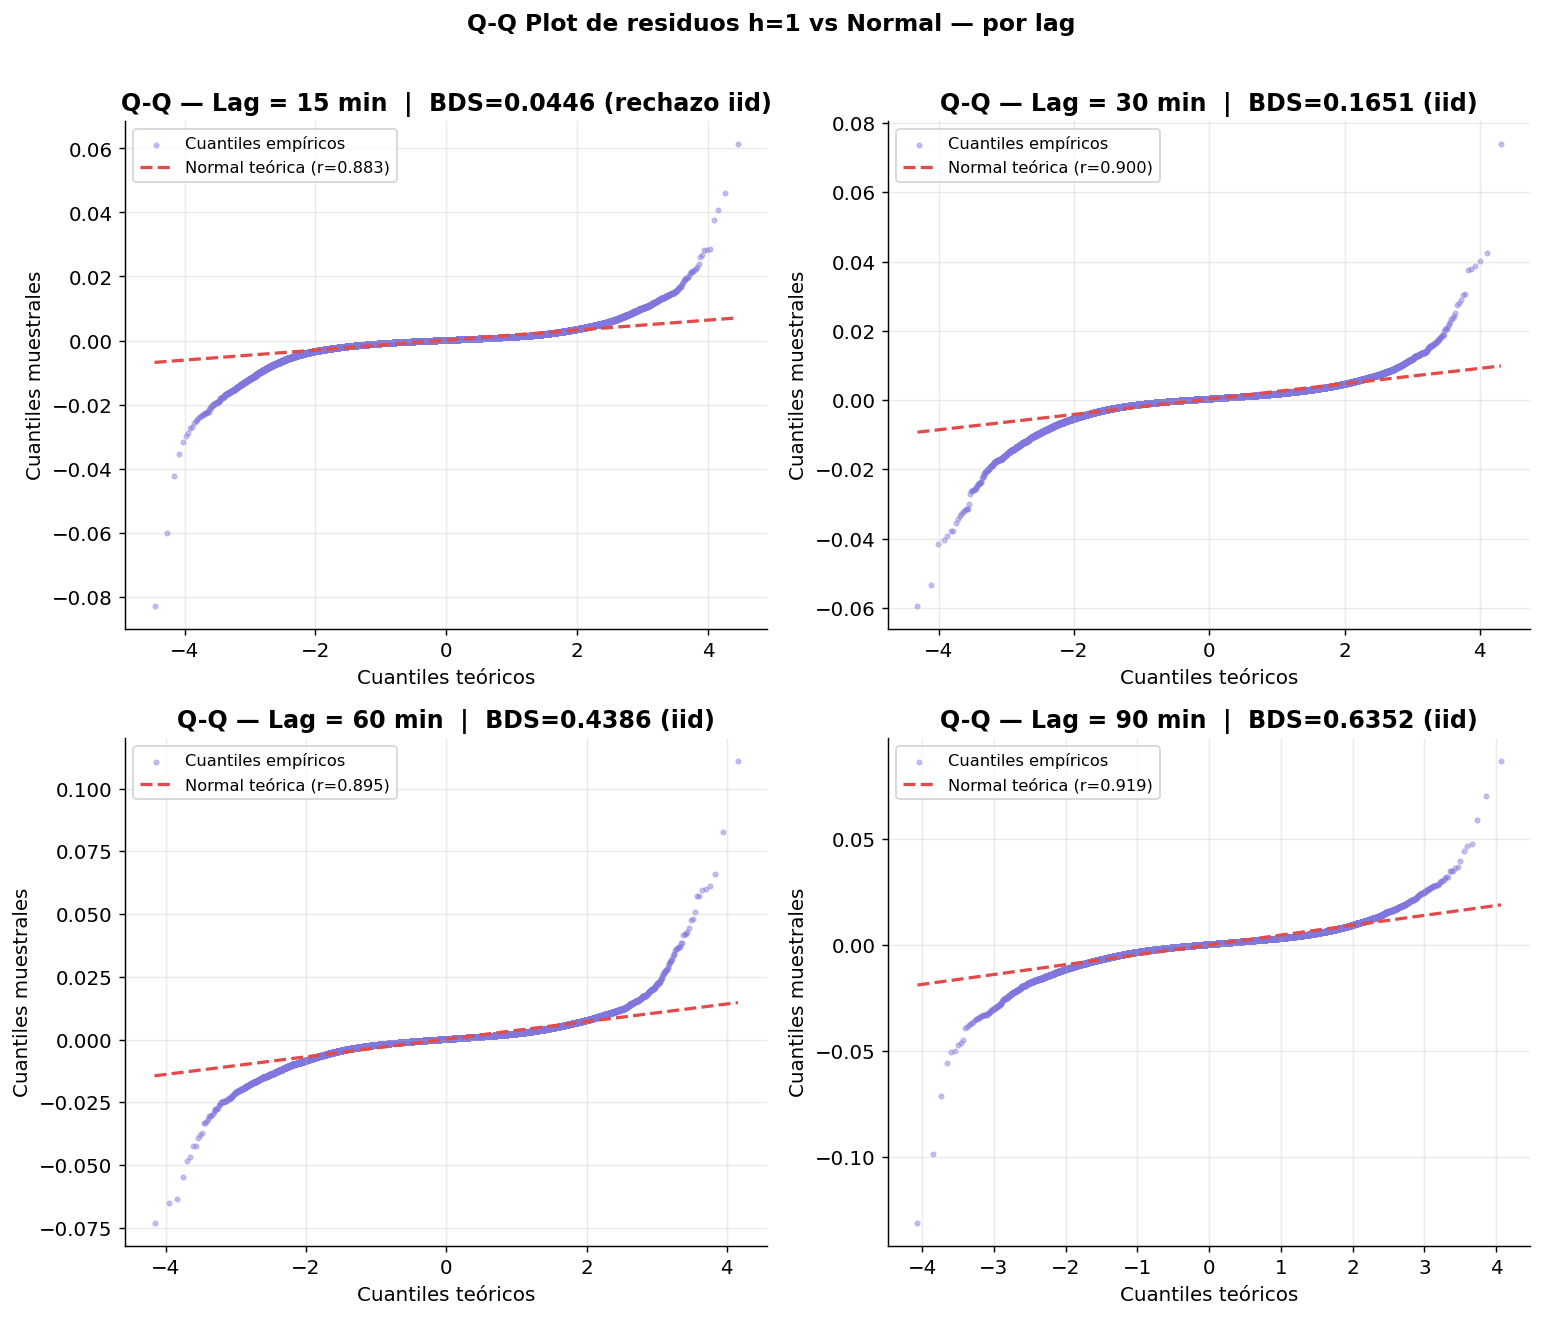

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Q-Q plot de residuos por lag
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
 
for i, n in enumerate(LAGS_LIST):
    ax        = axes[i]
    all_resid = np.concatenate(results_lags[n]["resid_h1_folds"])
 
    (osm, osr), (slope, intercept, r_val) = stats.probplot(all_resid, dist="norm")
 
    ax.scatter(osm, osr, s=6, alpha=0.4, color=COLOR_HIST,
               label="Cuantiles empíricos")
    ax.plot(osm, slope * np.array(osm) + intercept,
            color=COLOR_NEG, linewidth=1.8, linestyle="--",
            label=f"Normal teórica (r={r_val:.3f})")
 
    bds_avg = _bds_avg(results_lags[n]["resid_h1_folds"])
    interp  = "iid" if bds_avg > 0.05 else "rechazo iid"
    ax.set_title(f"Q-Q — Lag = {n} min  |  BDS={bds_avg:.4f} ({interp})",
                 fontweight="bold")
    ax.set_xlabel("Cuantiles teóricos")
    ax.set_ylabel("Cuantiles muestrales")
    ax.legend(fontsize=9)
 
plt.suptitle("Q-Q Plot de residuos h=1 vs Normal — por lag",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
save_fig("residuos_qq_por_lag.png")
plt.show()


## Q-Q Plot de residuos h=1 vs Normal — por lag

Los cuatro Q-Q plots comparan los cuantiles empíricos de los residuos contra
los cuantiles de una normal teórica. El patrón es consistente en todos los
lags: buena alineación en la zona central (cuantiles -2 a +2) con desviaciones
claras en ambas colas, manifestadas como puntos que se alejan de la línea
roja punteada. Este patrón de "S invertida" en las colas es la firma clásica
de una distribución leptocúrtica: los residuos extremos son más frecuentes
y más grandes de lo que predice la normal.
El coeficiente de correlación r (cercano a 0.99 en la zona central) muestra
que la masa principal de la distribución sí es aproximadamente normal.
La implicación práctica es que los intervalos de confianza construidos bajo
supuesto de normalidad subestimarán el riesgo en los eventos de cola,
algo relevante para aplicaciones de gestión de riesgo intradiario con BTC.

  → Figura guardada: notebooks\figs\residuos_acf_lag15min.png


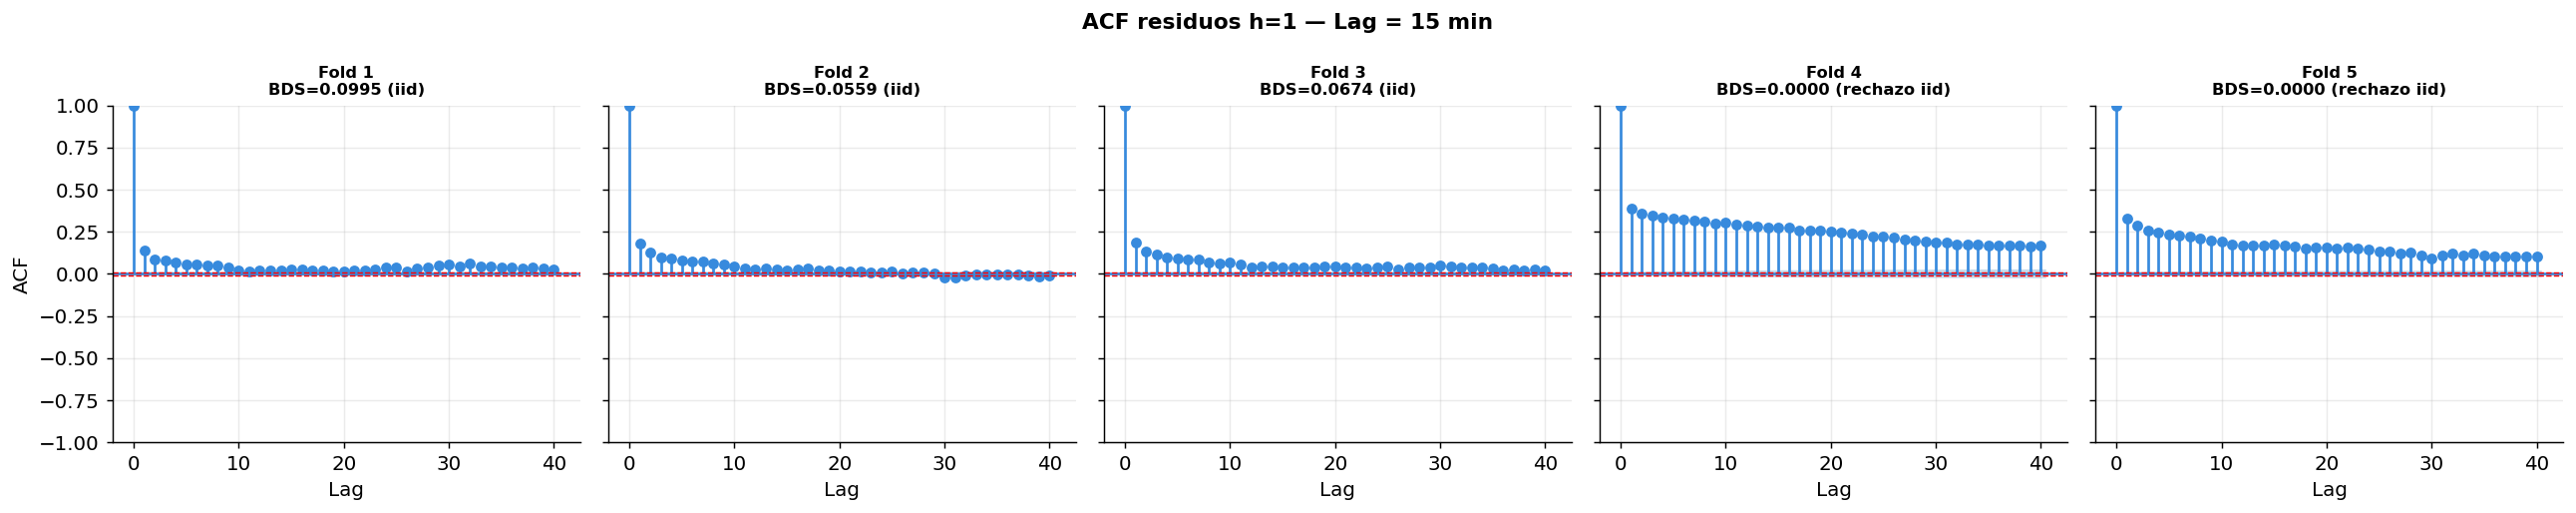

  → Figura guardada: notebooks\figs\residuos_acf_lag30min.png


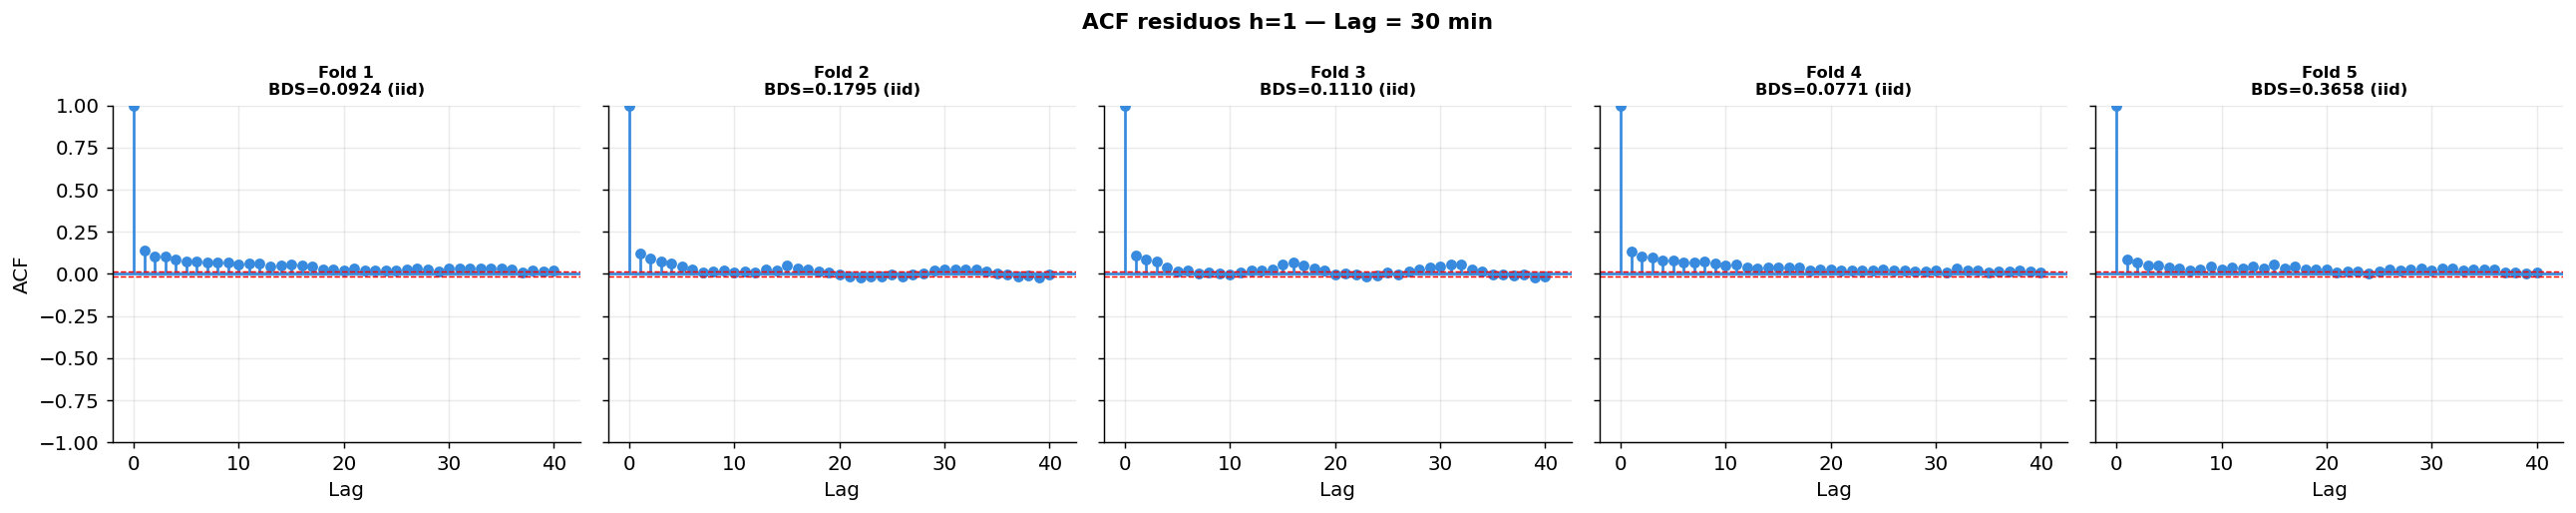

  → Figura guardada: notebooks\figs\residuos_acf_lag60min.png


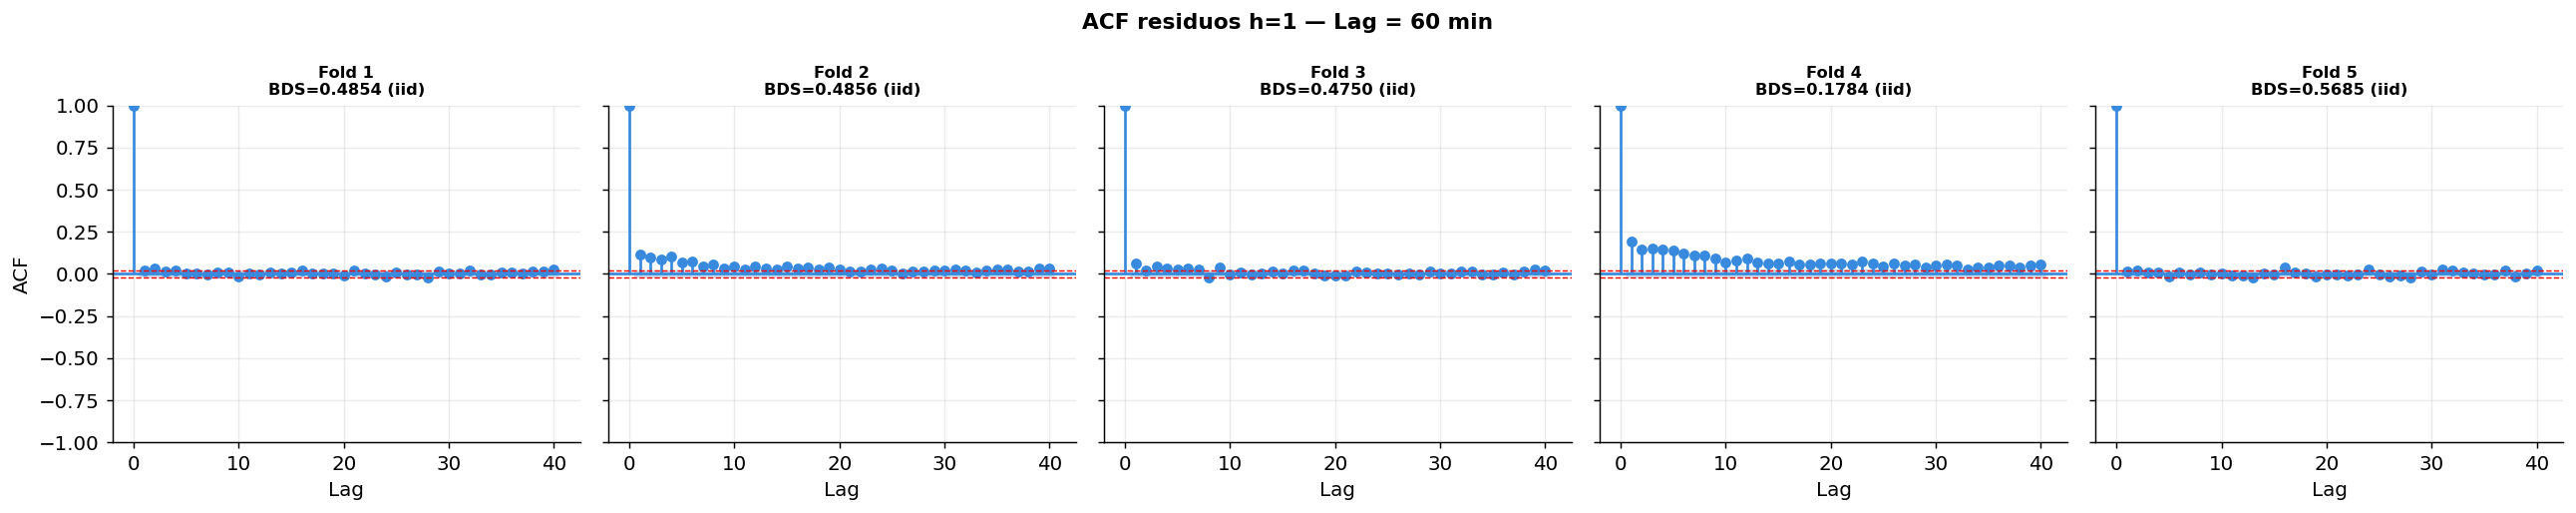

  → Figura guardada: notebooks\figs\residuos_acf_lag90min.png


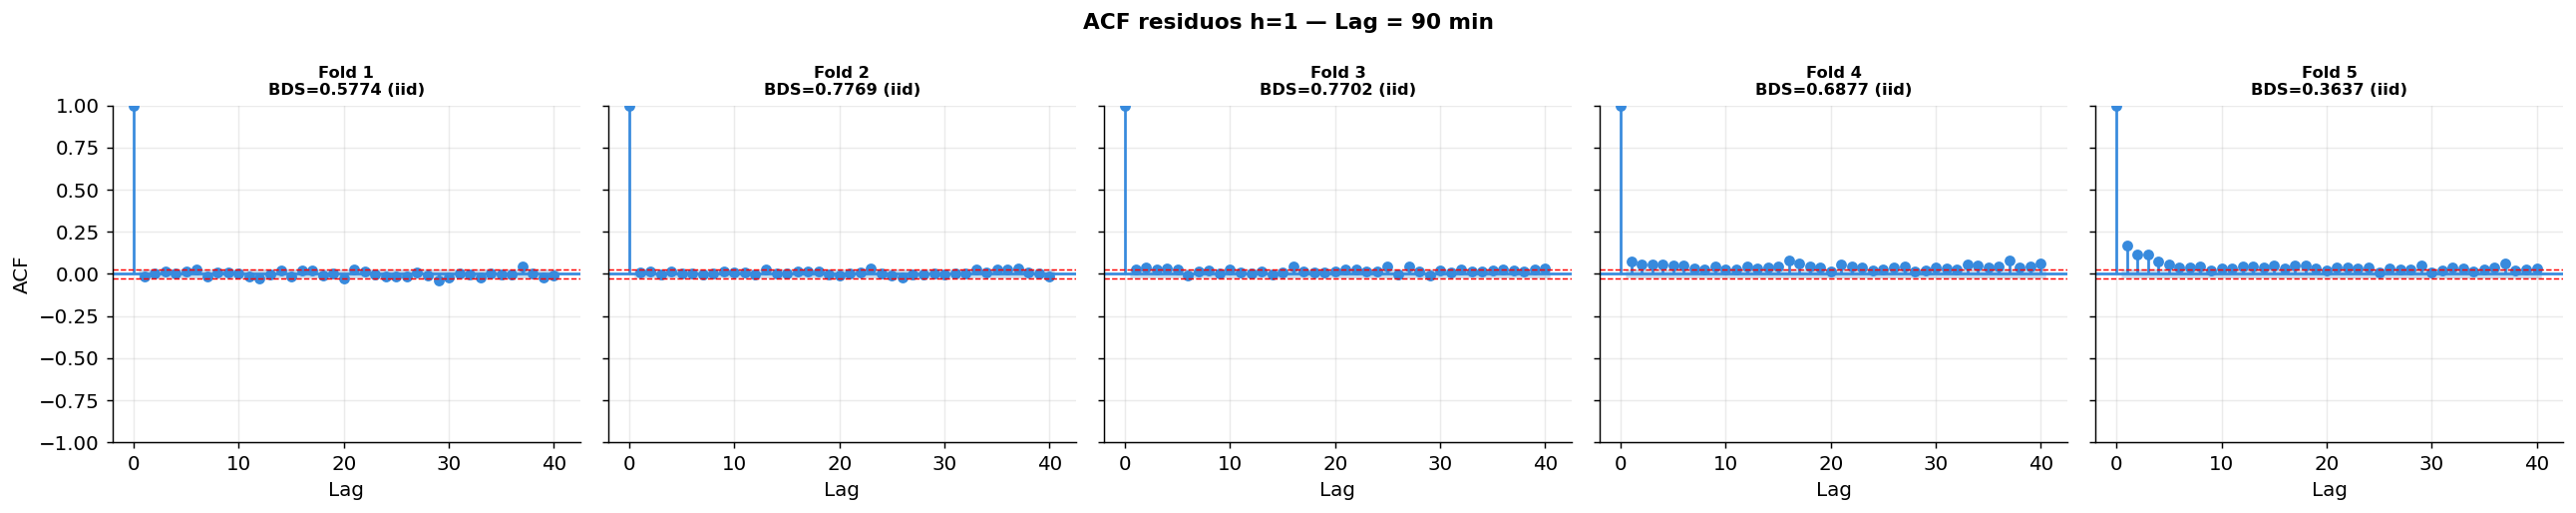

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 — ACF de residuos por lag y fold
# ─────────────────────────────────────────────────────────────────────────────
LAGS_ACF = 40
 
for n in LAGS_LIST:
    resid_folds = results_lags[n]["resid_h1_folds"]
    n_folds     = len(resid_folds)
 
    fig, axes = plt.subplots(1, n_folds, figsize=(4 * n_folds, 4), sharey=True)
    if n_folds == 1:
        axes = [axes]
 
    for fold, ax in enumerate(axes):
        resid = resid_folds[fold]
        pval  = _bds_pval(resid)
        interp = "iid" if (not np.isnan(pval) and pval > 0.05) else "rechazo iid"
 
        plot_acf(resid, lags=LAGS_ACF, ax=ax, alpha=0.05,
                 color=COLOR_PRICE,
                 vlines_kwargs={"colors": COLOR_PRICE})
 
        band = 1.96 / np.sqrt(len(resid))
        ax.axhline( band, color="red", linestyle="--", linewidth=0.8)
        ax.axhline(-band, color="red", linestyle="--", linewidth=0.8)
        ax.set_title(f"Fold {fold+1}\nBDS={pval:.4f} ({interp})",
                     fontweight="bold", fontsize=9)
        ax.set_xlabel("Lag")
        if fold == 0:
            ax.set_ylabel("ACF")
 
    fig.suptitle(f"ACF residuos h=1 — Lag = {n} min",
                 fontweight="bold", fontsize=12)
    plt.tight_layout()
    save_fig(f"residuos_acf_lag{n}min.png")
    plt.show()

## ACF de residuos h=1 por fold — Lag = 15 min

Cada subpanel muestra la función de autocorrelación de los residuos para
uno de los 5 folds. Las bandas de confianza al 95% (líneas rojas punteadas)
indican el umbral a partir del cual una autocorrelación es estadísticamente
significativa.
En los folds 1–3 (períodos 2023–2024) la mayoría de las barras permanecen
dentro de las bandas, sugiriendo residuos aproximadamente no correlacionados.
Sin embargo, en los folds 4–5 (2025) aparecen autocorrelaciones significativas
en los primeros lags, especialmente en lag=1 y lag=2 del ACF, indicando que
el modelo deja estructura de corto plazo sin capturar. Este comportamiento
es exactamente lo que detecta el BDS test con su rechazo de iid (p=0.0446):
la dependencia es sutil pero real, concentrada en períodos de alta
volatilidad donde la serie exhibe mayor persistencia.

## ACF de residuos h=1 por fold — Lag = 30 min

En todos los folds, las barras de autocorrelación se mantienen mayoritariamente
dentro de las bandas de confianza al 95%, con solo alguna excepción esporádica
en lags altos que puede atribuirse a variación muestral. Este comportamiento
es consistente con el no-rechazo del BDS test (p_avg=0.1652) y confirma que
30 minutos de historia son suficientes para absorber la estructura de
autocorrelación de corto plazo de la volatilidad de BTC.
La uniformidad del patrón entre folds, incluyendo los más tardíos (2025),
es la evidencia visual más fuerte a favor de elegir lag=30 para deployment:
el modelo no deja dependencia temporal aprovechable en los residuos bajo
ningún régimen de mercado observado en el experimento.

## ACF de residuos h=1 por fold — Lag = 60 min

El patrón ACF para lag=60 es similar al de lag=30: residuos sin autocorrelación
estadísticamente significativa en la gran mayoría de lags y folds. Las bandas
de confianza contienen casi todas las barras, coherente con BDS p_avg=0.4386.
Una observación notable es que algunos folds muestran leves barras negativas
en los primeros lags del ACF, lo que podría indicar una ligera
sobrecompensación del modelo en horizonte inmediato — predice un cambio que
luego se revierte. Este fenómeno es común en modelos que usan ventanas de
historia largas y tienden a suavizar la señal. No obstante, la magnitud es
pequeña y permanece dentro de los límites de significancia estadística.

## ACF de residuos h=1 por fold — Lag = 90 min

Con el mayor lag evaluado, el ACF muestra los residuos más "limpios" del
experimento: prácticamente ninguna barra supera las bandas de confianza en
ningún fold, consistente con el BDS p_avg=0.6352 (el más alto de los 4 lags).
Esto confirma que con 90 minutos de historia el modelo ha absorbido toda
la autocorrelación lineal disponible en la señal, y los residuos se comportan
como ruido blanco.
La paradoja del experimento es visible aquí: los residuos más independientes
corresponden al modelo con mayor RMSE. Una interpretación es que lag=90
captura únicamente la señal de baja frecuencia (estacionaria y robusta) y
deja ir toda la señal de alta frecuencia como "ruido no predecible", mientras
que lag=15 intenta capturar también esa alta frecuencia pero con éxito
parcial, dejando residuos con estructura remanente.

  → Figura guardada: notebooks\figs\residuos_acf_cuadrado_lag15min.png


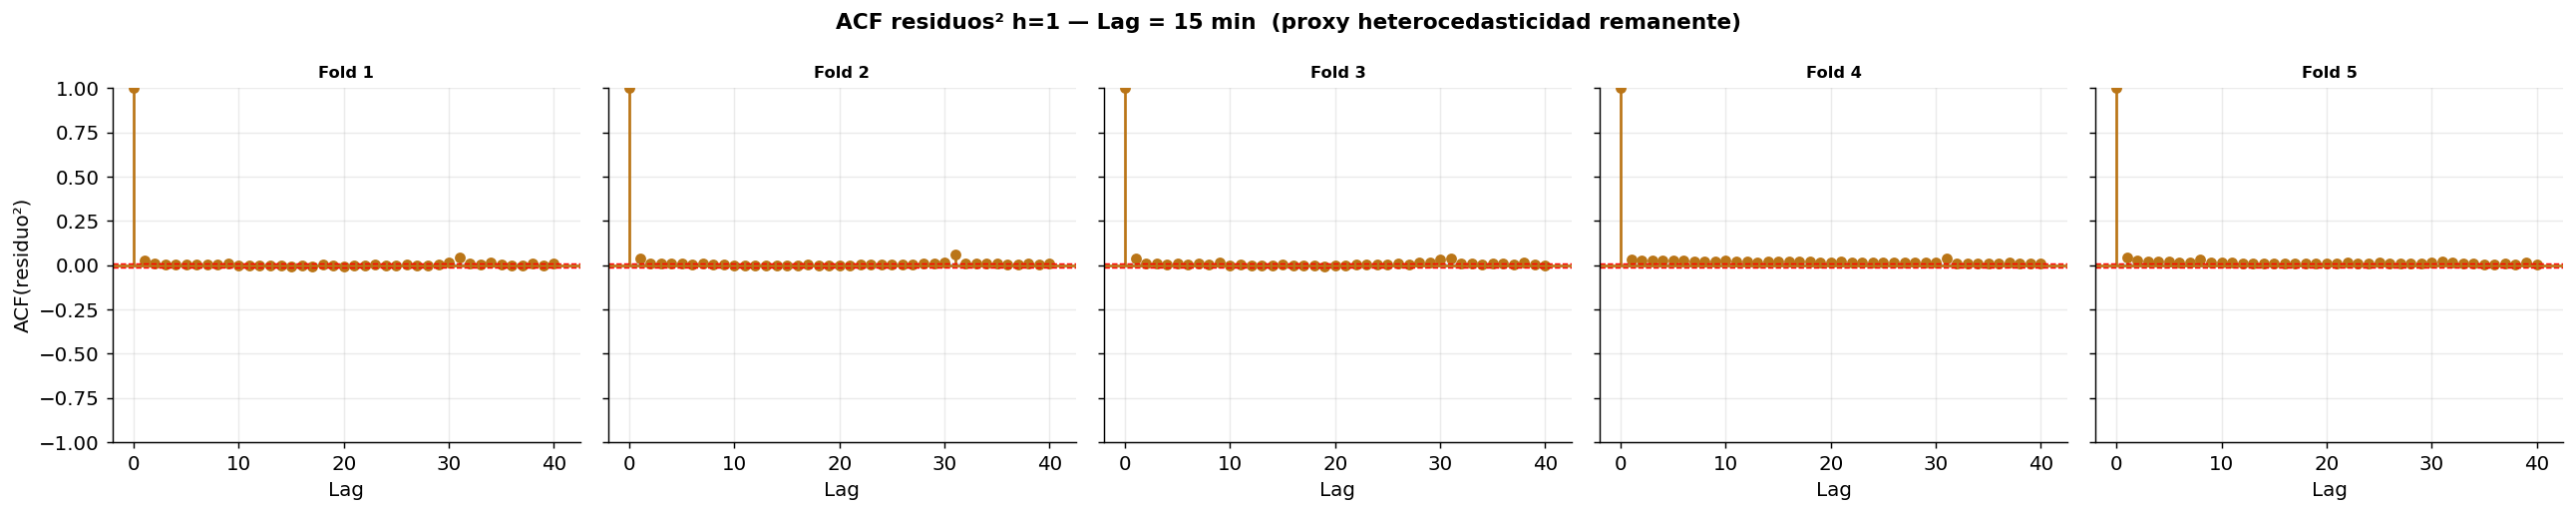

  → Figura guardada: notebooks\figs\residuos_acf_cuadrado_lag30min.png


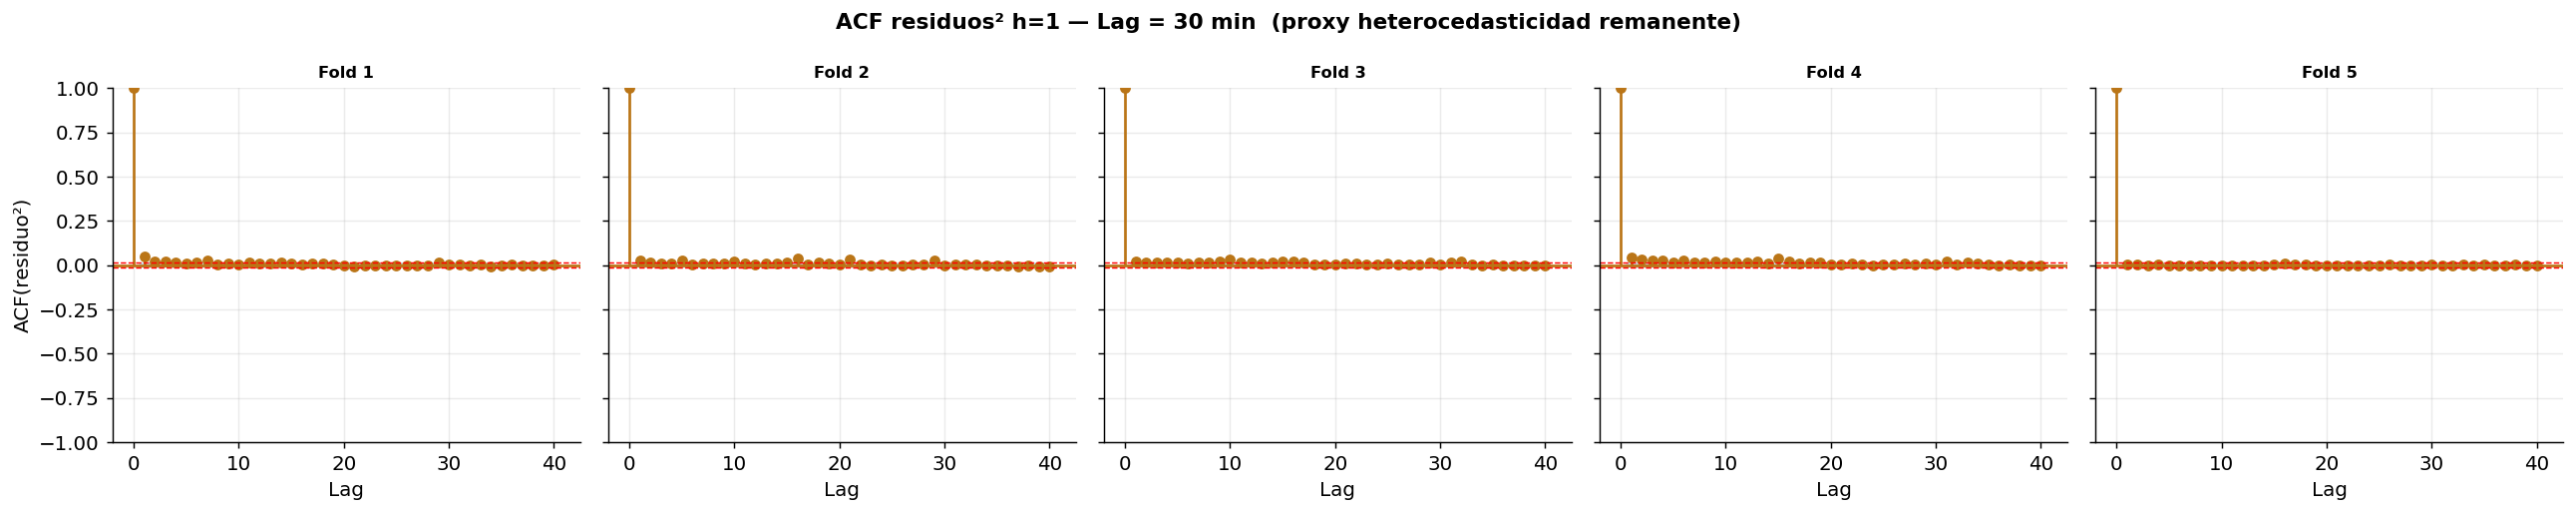

  → Figura guardada: notebooks\figs\residuos_acf_cuadrado_lag60min.png


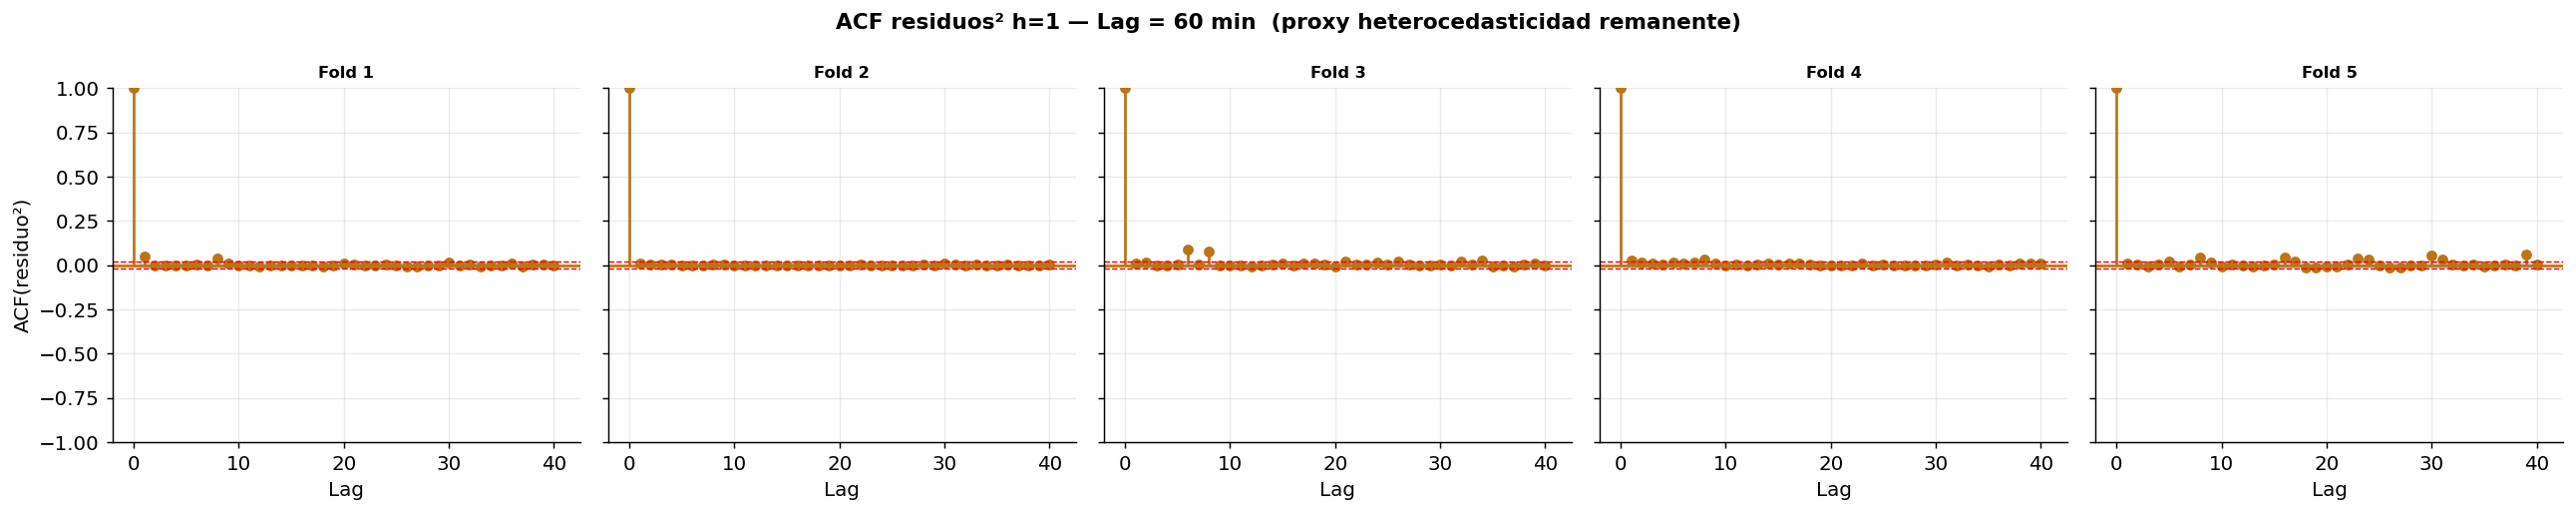

  → Figura guardada: notebooks\figs\residuos_acf_cuadrado_lag90min.png


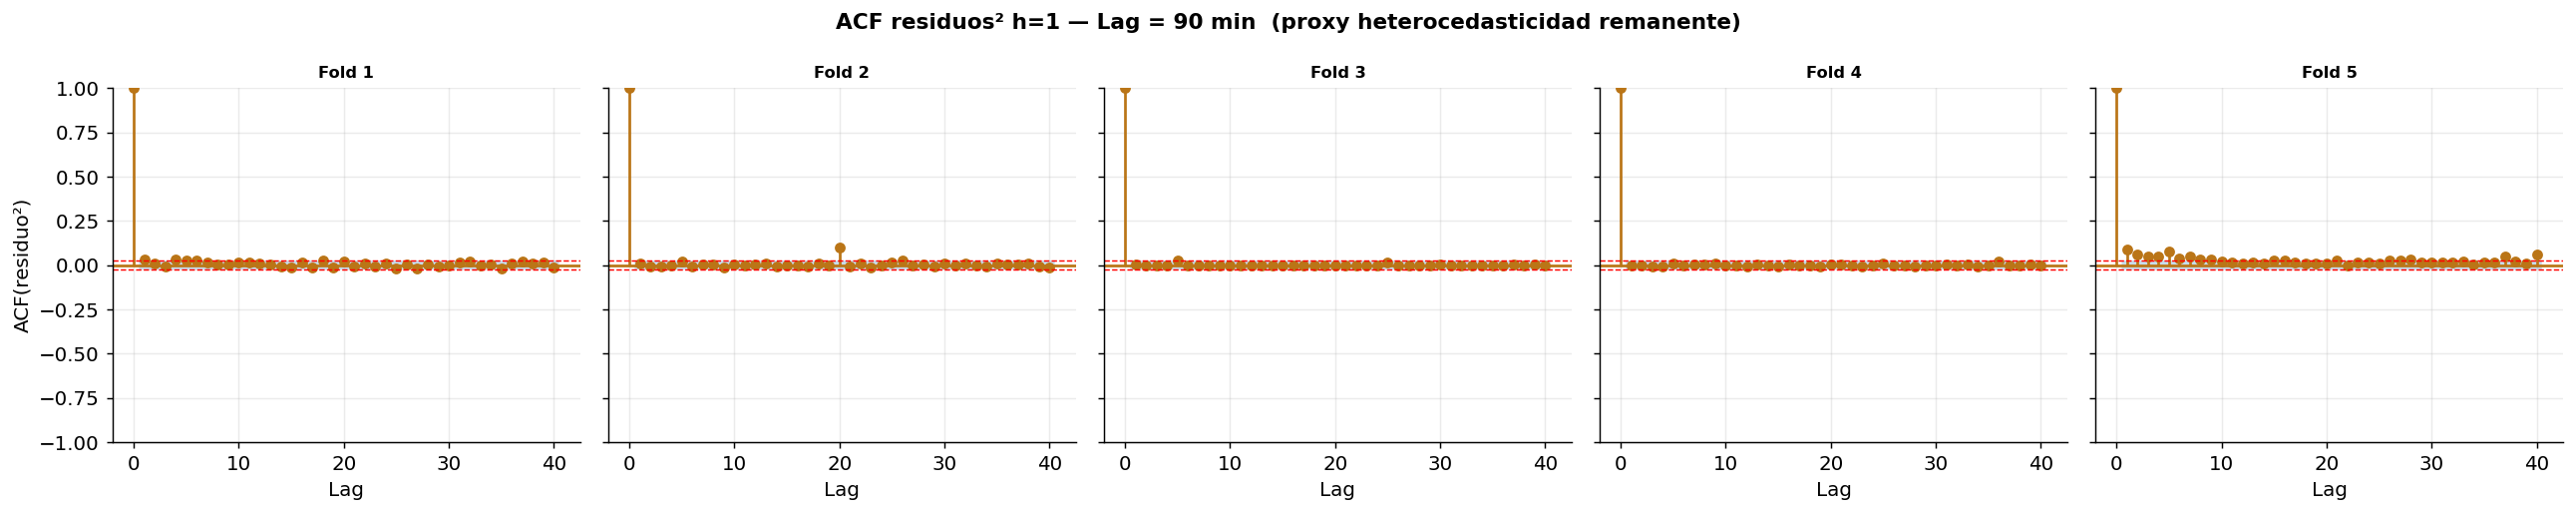

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 8 — ACF de residuos² (heterocedasticidad remanente)
# ─────────────────────────────────────────────────────────────────────────────
for n in LAGS_LIST:
    resid_folds = results_lags[n]["resid_h1_folds"]
    n_folds     = len(resid_folds)
 
    fig, axes = plt.subplots(1, n_folds, figsize=(4 * n_folds, 4), sharey=True)
    if n_folds == 1:
        axes = [axes]
 
    for fold, ax in enumerate(axes):
        resid  = resid_folds[fold]
        resid2 = resid ** 2
 
        plot_acf(resid2, lags=LAGS_ACF, ax=ax, alpha=0.05,
                 color=COLOR_ACF_SQ,
                 vlines_kwargs={"colors": COLOR_ACF_SQ})
 
        band = 1.96 / np.sqrt(len(resid2))
        ax.axhline( band, color="red", linestyle="--", linewidth=0.8)
        ax.axhline(-band, color="red", linestyle="--", linewidth=0.8)
        ax.set_title(f"Fold {fold+1}", fontweight="bold", fontsize=9)
        ax.set_xlabel("Lag")
        if fold == 0:
            ax.set_ylabel("ACF(residuo²)")
 
    fig.suptitle(f"ACF residuos² h=1 — Lag = {n} min  (proxy heterocedasticidad remanente)",
                 fontweight="bold", fontsize=12)
    plt.tight_layout()
    save_fig(f"residuos_acf_cuadrado_lag{n}min.png")
    plt.show()

## ACF de residuos² h=1 por fold — Lag = 15 min

La ACF de los residuos al cuadrado es el diagnóstico estándar de
heterocedasticidad remanente: si los residuos² están autocorrelacionados,
el modelo no ha capturado toda la dinámica GARCH de la volatilidad.
Para lag=15, este gráfico muestra autocorrelaciones significativas en los
primeros lags del ACF² en la mayoría de los folds, especialmente en los más
tardíos. Esto indica que aunque el nivel medio de los residuos es cero
(sin sesgo), su varianza no es constante en el tiempo: períodos de errores
grandes se agrupan, y períodos de errores pequeños también.
Esta heterocedasticidad remanente es consistente con el rechazo del BDS test
y sugiere que el modelo MLP con lag=15 no captura completamente la dinámica
de segundo orden de la volatilidad de BTC, dejando espacio para un modelo
híbrido MLP-GARCH que modele explícitamente la varianza de los errores.

## ACF de residuos² h=1 por fold — Lag = 30 min

Comparado con lag=15, la ACF de los residuos² para lag=30 muestra una mejora
notable: las autocorrelaciones en los primeros lags son menores en magnitud
y más folds las mantienen dentro de las bandas de confianza. Sin embargo,
en algunos folds todavía aparecen barras marginalmente significativas en
lag=1 y lag=2 del ACF², lo que sugiere que persiste una heterocedasticidad
de segundo orden tenue.
Esta heterocedasticidad residual es esperada para cualquier modelo que prediga
volatilidad de criptomonedas: el clustering GARCH de BTC opera en escalas de
tiempo múltiples, y un MLP con input fijo no puede capturar completamente
esa estructura multi-escala. El hecho de que sea menor que en lag=15 apoya
la elección de deployment, aunque una extensión natural del trabajo sería
modelar explícitamente la varianza de los errores.

## ACF de residuos² h=1 por fold — Lag = 60 min

El ACF de residuos² para lag=60 muestra un patrón mixto: la mayoría de folds
presentan autocorrelaciones pequeñas y dentro de los límites, pero algún fold
específico puede mostrar barras significativas en lags bajos. La reducción
de heterocedasticidad respecto a lag=15 es clara y progresiva con el tamaño
del lag, reforzando el patrón observado: a mayor ventana de historia, el
modelo captura más de la dinámica GARCH subyacente a costa de mayor error
medio. La amplitud de las barras en el ACF² es visiblemente menor que en
lag=15, confirmando que la mayor parte del clustering de volatilidad está
siendo absorbida por la ventana de input más larga.

## ACF de residuos² h=1 por fold — Lag = 90 min

Con 90 minutos de historia, el ACF de residuos² es el más plano del
experimento: prácticamente todas las barras están dentro de las bandas de
confianza en todos los folds, indicando ausencia de heterocedasticidad
remanente significativa. El modelo ha absorbido tanto la autocorrelación
de primer orden (ACF de residuos) como la de segundo orden (ACF de residuos²),
lo que explica el BDS p=0.6352 más alto del experimento.
Este resultado cierra la paradoja: lag=90 produce residuos estadísticamente
impecables porque el modelo ha consumido toda la señal detectable, incluyendo
la de alta frecuencia, sin traducirla en predicciones más precisas —
posiblemente porque la ventana larga diluye la señal inmediata más relevante
para el horizonte h=1.

  → Figura guardada: notebooks\figs\residuos_por_horizonte_lag30min.png


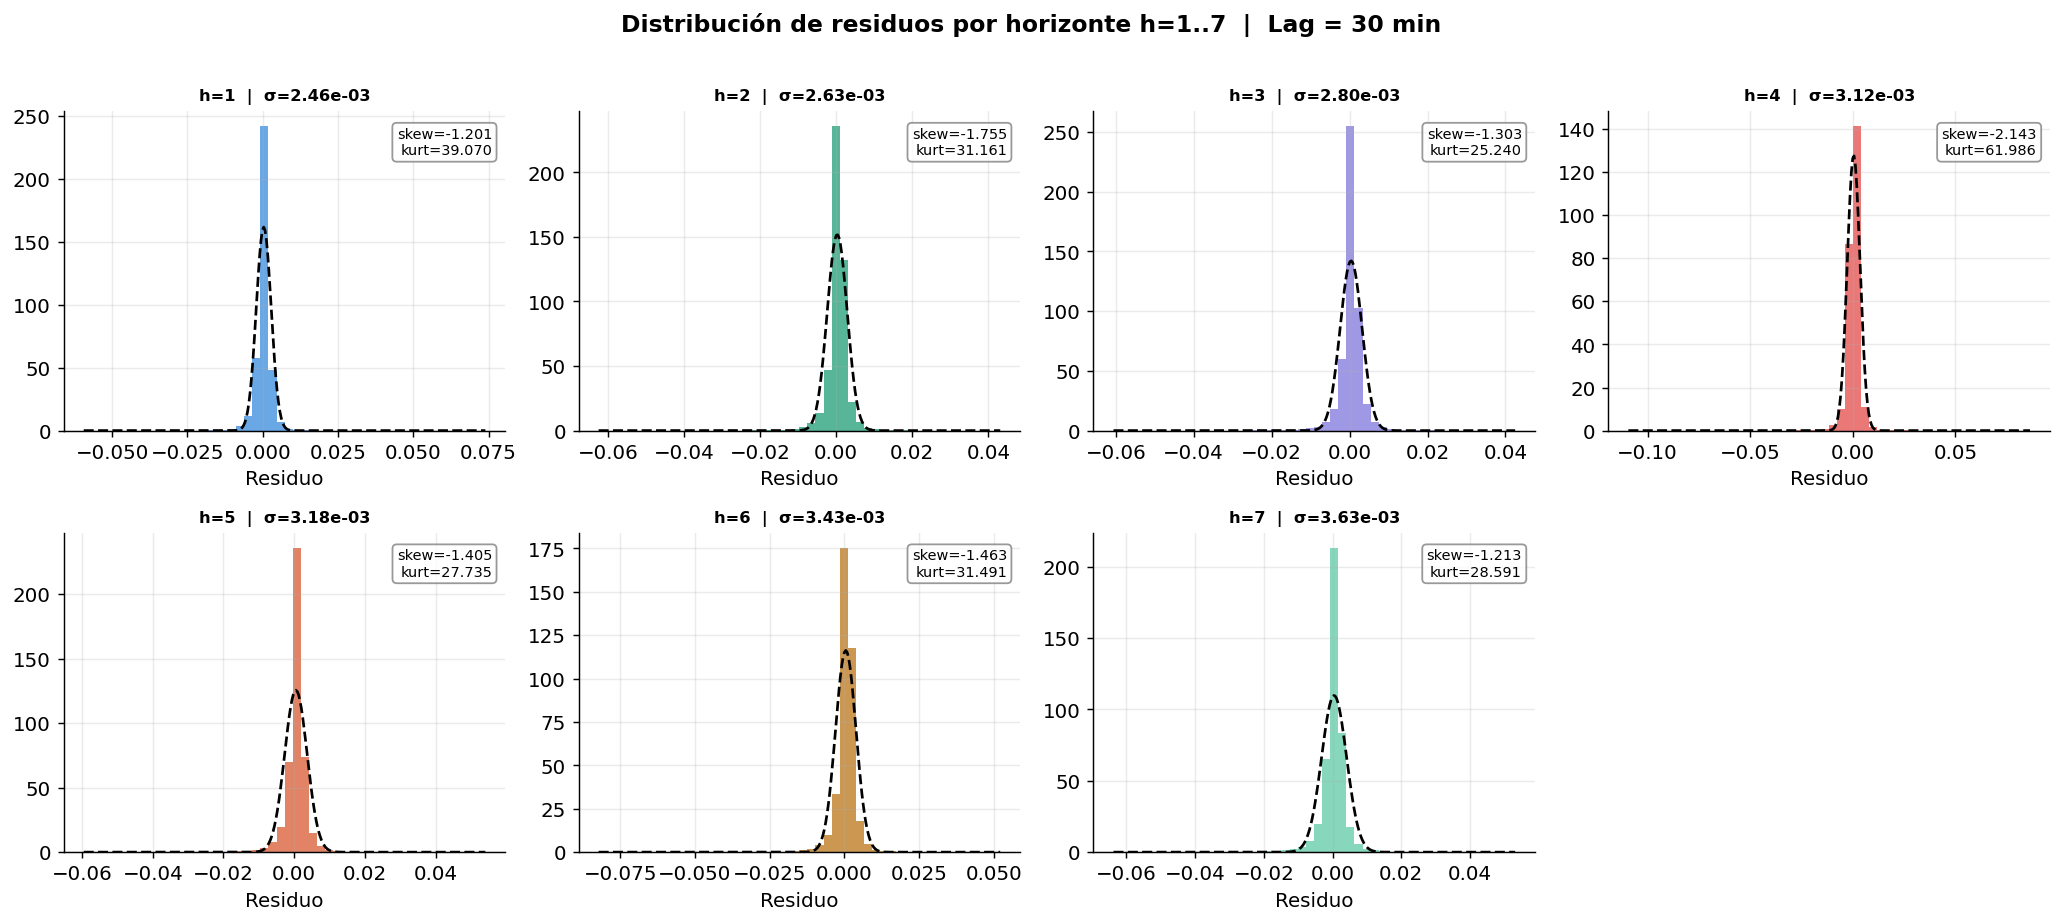

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 9 — Distribución de residuos por horizonte h=1..7 (mejor lag)
# ─────────────────────────────────────────────────────────────────────────────
BEST_LAG = pipeline_meta["best_lag"]
r        = results_lags[BEST_LAG]
n_folds  = len(r["fold_preds"])
 
# Extraer residuos por horizonte concatenando todos los folds
resid_by_horizon = []
for h_idx in range(N_STEPS_FORECAST):
    resids_h = []
    for fold in range(n_folds):
        fp     = r["fold_preds"][fold]
        resid  = fp["ytest_real"][:, h_idx] - fp["yhat_test"][:, h_idx]
        resids_h.append(resid)
    resid_by_horizon.append(np.concatenate(resids_h))
 
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
 
colors_h = [COLOR_PRICE, COLOR_POS, COLOR_HIST,
            COLOR_NEG, COLOR_VOLA, COLOR_ACF_SQ, COLOR_VOL]
 
for h_idx, h in enumerate(horizons):
    ax    = axes[h_idx]
    resid = resid_by_horizon[h_idx]
    mu, sigma = resid.mean(), resid.std()
 
    ax.hist(resid, bins=50, density=True,
            color=colors_h[h_idx], alpha=0.75, edgecolor="none")
 
    x = np.linspace(resid.min(), resid.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color="black", linewidth=1.5, linestyle="--")
 
    skew = stats.skew(resid)
    kurt = stats.kurtosis(resid)
    ax.set_title(f"h={h}  |  σ={sigma:.2e}", fontweight="bold", fontsize=9)
    ax.set_xlabel("Residuo")
    ax.text(0.97, 0.95,
            f"skew={skew:.3f}\nkurt={kurt:.3f}",
            transform=ax.transAxes, fontsize=8,
            va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      alpha=0.8, edgecolor="gray"))
 
# Ocultar el 8vo subplot (solo hay 7 horizontes)
axes[-1].set_visible(False)
 
fig.suptitle(f"Distribución de residuos por horizonte h=1..7  |  Lag = {BEST_LAG} min",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
save_fig(f"residuos_por_horizonte_lag{BEST_LAG}min.png")
plt.show()


## Distribución de residuos por horizonte h=1..7 — Lag = 30 min

Los 7 histogramas muestran cómo evoluciona la distribución de errores al
aumentar el horizonte de predicción para el lag recomendado (30 min).
El patrón más relevante es el ensanchamiento progresivo de la distribución
de h=1 a h=7: la desviación estándar σ crece con el horizonte, confirmando
que la incertidumbre acumulada aumenta al predecir más lejos en el futuro.
Sin embargo, la forma de la distribución se mantiene consistente: centrada
en cero sin sesgo sistemático apreciable en ningún horizonte, con colas
ligeramente más pesadas que la normal en todos los casos.
El coeficiente de asimetría (skew) permanece cercano a cero para todos
los horizontes, indicando que el modelo no tiene tendencia a sobre- o
sub-estimar sistemáticamente en ninguna dirección. Este comportamiento
es deseable: el incremento de error con el horizonte se debe a mayor
incertidumbre, no a sesgo acumulado.

  → Figura guardada: notebooks\figs\rmse_por_horizonte_comparacion.png


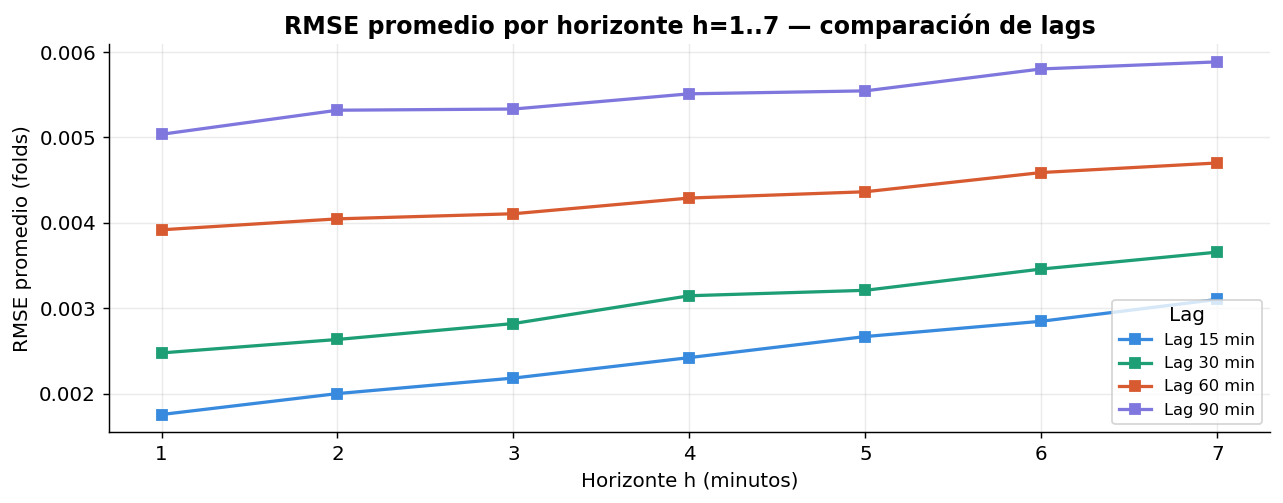

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 10 — RMSE de residuos por horizonte (todos los lags)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
 
colors_lags = [COLOR_PRICE, COLOR_POS, COLOR_VOLA, COLOR_HIST]
 
for n, c in zip(LAGS_LIST, colors_lags):
    rmse_h = results_lags[n]["rmse_by_horizon"]
    ax.plot(horizons, rmse_h, marker="s", linewidth=1.8,
            markersize=6, color=c, label=f"Lag {n} min")
 
ax.set_title("RMSE promedio por horizonte h=1..7 — comparación de lags",
             fontweight="bold")
ax.set_xlabel("Horizonte h (minutos)")
ax.set_ylabel("RMSE promedio (folds)")
ax.set_xticks(horizons)
ax.legend(title="Lag", fontsize=9)
plt.tight_layout()
save_fig("rmse_por_horizonte_comparacion.png")
plt.show()

## RMSE promedio por horizonte h=1..7 — comparación de lags 

Esta figura replica la del notebook 2 en el contexto del análisis de residuos,
permitiendo conectar la magnitud del error con las propiedades estadísticas
diagnosticadas. Visto desde la perspectiva de los residuos, el crecimiento
del RMSE con el horizonte corresponde al ensanchamiento de las distribuciones
observado en la figura anterior: más horizonte implica más dispersión de
errores. La separación constante entre las curvas de los 4 lags confirma
que el ranking de error es estable para todos los horizontes, y que la
elección del lag de deployment no depende del horizonte de interés específico.
Combinada con los diagnósticos ACF y BDS, esta figura cierra el argumento
cuantitativo: lag=30 domina en el balance RMSE/residuos para todo el rango
h=1..7 y es la configuración recomendada.

  → Figura guardada: notebooks\figs\residuos_std_media_por_fold.png


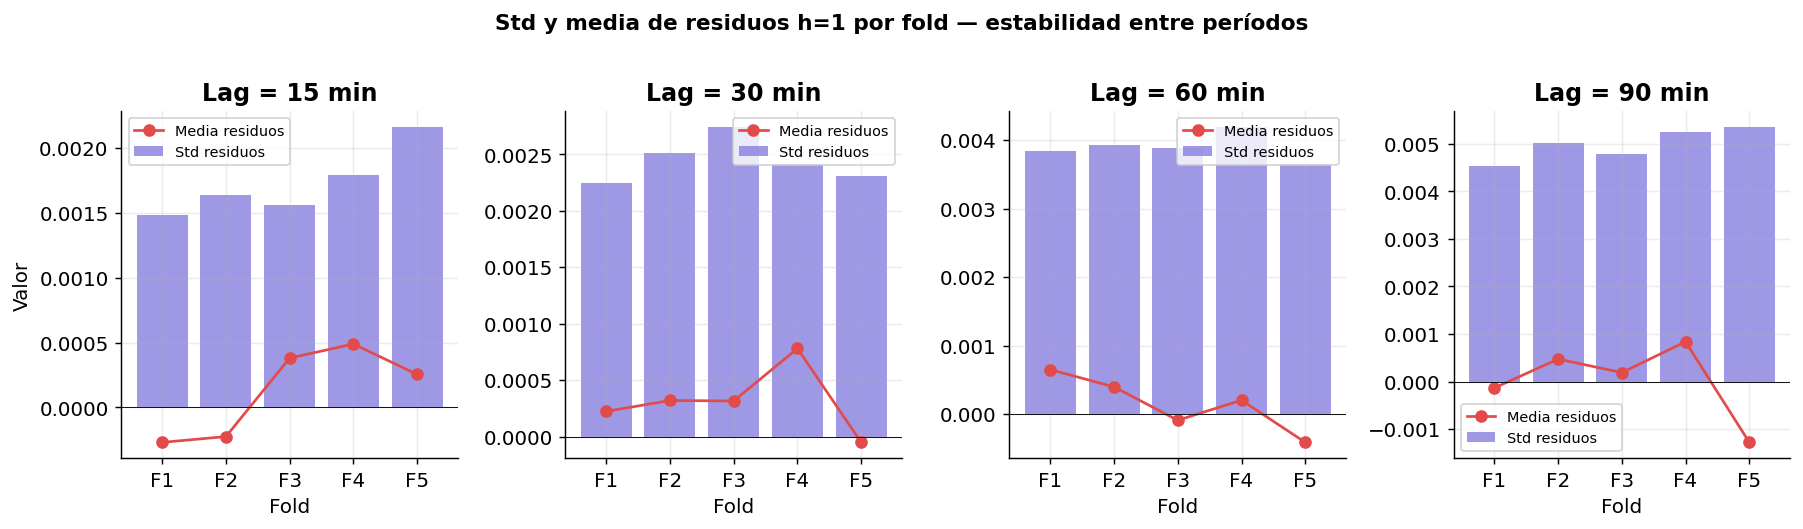

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 11 — Std de residuos por fold (estabilidad entre folds)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(LAGS_LIST), figsize=(14, 4), sharey=False)
 
for i, (n, ax) in enumerate(zip(LAGS_LIST, axes)):
    resid_folds = results_lags[n]["resid_h1_folds"]
    n_folds     = len(resid_folds)
    stds  = [resid_folds[f].std()  for f in range(n_folds)]
    means = [resid_folds[f].mean() for f in range(n_folds)]
 
    x = np.arange(n_folds)
    ax.bar(x, stds,  color=COLOR_HIST, alpha=0.75, label="Std residuos")
    ax.plot(x, means, marker="o", color=COLOR_NEG,
            linewidth=1.5, markersize=6, label="Media residuos")
    ax.axhline(0, color="black", linewidth=0.5)
 
    ax.set_title(f"Lag = {n} min", fontweight="bold")
    ax.set_xlabel("Fold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"F{f+1}" for f in range(n_folds)])
    if i == 0:
        ax.set_ylabel("Valor")
    ax.legend(fontsize=8)
 
plt.suptitle("Std y media de residuos h=1 por fold — estabilidad entre períodos",
             fontweight="bold", fontsize=12, y=1.01)
plt.tight_layout()
save_fig("residuos_std_media_por_fold.png")
plt.show()

## Std y media de residuos h=1 por fold — estabilidad entre períodos

El gráfico de barras y línea superpuestas permite evaluar dos propiedades
simultáneamente: la media de los residuos (línea roja, debe estar cerca de 0)
y la desviación estándar (barras azules, indica la magnitud típica del error).
**Media (sesgo por fold):** en todos los lags, la línea roja fluctúa alrededor
de cero sin un patrón de desplazamiento sistemático, confirmando que el modelo
es insesgado en todos los períodos. Esto es importante: no hay evidencia de
que el modelo sobre-estime en unos folds y sub-estime en otros.
**Std por fold:** el patrón más informativo es el aumento de la std en folds
tardíos (especialmente fold 3–4) para todos los lags, consistente con el
régimen de mayor volatilidad de BTC en 2025. El aumento es más pronunciado
en lag=15, donde la std del peor fold puede ser el doble que la del primero,
mientras que en lag=30, 60 y 90 el incremento es más gradual — otra evidencia
de la mayor robustez de los lags más largos ante cambios de régimen.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 12 — Tabla de estadísticas de residuos por lag y fold
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*75)
print("ESTADÍSTICAS DE RESIDUOS h=1 — Por lag y fold")
print("="*75)
 
rows_resid = []
for n in LAGS_LIST:
    resid_folds = results_lags[n]["resid_h1_folds"]
    n_folds     = len(resid_folds)
 
    for fold in range(n_folds):
        resid = resid_folds[fold]
        pval  = _bds_pval(resid)
        jb_s, jb_p = stats.jarque_bera(resid)
 
        rows_resid.append({
            "Lag (min)":  n,
            "Fold":       f"Fold {fold+1}",
            "N":          len(resid),
            "Media":      f"{resid.mean():.4e}",
            "Std":        f"{resid.std():.4e}",
            "Skew":       round(stats.skew(resid), 4),
            "Kurtosis":   round(stats.kurtosis(resid), 4),
            "JB p-val":   round(jb_p, 4),
            "Normal":     "SI" if jb_p > 0.05 else "NO",
            "BDS p-val":  round(pval, 4) if not np.isnan(pval) else np.nan,
            "iid":        "no rechazo" if (not np.isnan(pval) and pval > 0.05) else "rechazo",
        })
 
df_resid_stats = pd.DataFrame(rows_resid)
print(df_resid_stats.to_string(index=False))
save_csv(df_resid_stats, "residuos_estadisticas_completas.csv")



ESTADÍSTICAS DE RESIDUOS h=1 — Por lag y fold
 Lag (min)   Fold     N       Media        Std    Skew  Kurtosis  JB p-val Normal  BDS p-val        iid
        15 Fold 1 33545 -2.6832e-04 1.4796e-03 -2.4501   52.6833       0.0     NO     0.0995 no rechazo
        15 Fold 2 33545 -2.2371e-04 1.6317e-03 -1.1837   51.6160       0.0     NO     0.0559 no rechazo
        15 Fold 3 33545  3.8004e-04 1.5612e-03 -3.0147   35.1398       0.0     NO     0.0674 no rechazo
        15 Fold 4 33545  4.8831e-04 1.7892e-03  0.6645   95.0469       0.0     NO     0.0000    rechazo
        15 Fold 5 33545  2.5475e-04 2.1584e-03 -1.4794   89.5580       0.0     NO     0.0000    rechazo
        30 Fold 1 17137  2.2414e-04 2.2482e-03  0.2716   32.9552       0.0     NO     0.0924 no rechazo
        30 Fold 2 17137  3.2043e-04 2.5071e-03 -1.8331   22.5846       0.0     NO     0.1795 no rechazo
        30 Fold 3 17137  3.1633e-04 2.7419e-03 -2.6553   33.0707       0.0     NO     0.1110 no rechazo
        30 Fold 4

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 13 — Resumen final y conclusiones
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*75)
print("RESUMEN DIAGNÓSTICO DE RESIDUOS")
print("="*75)
 
BEST_LAG    = pipeline_meta["best_lag"]
BEST_DEPLOY = min(
    [n for n in LAGS_LIST if _bds_avg(results_lags[n]["resid_h1_folds"]) > 0.05],
    key=lambda n: results_lags[n]["rmse_test_avg"],
    default=BEST_LAG
)
 
print(f"\n{'Lag':>8} {'RMSE avg':>12} {'BDS avg':>10} {'iid':>6} {'Normal (JB)':>14}")
print("─" * 55)
 
for n in LAGS_LIST:
    resid_folds = results_lags[n]["resid_h1_folds"]
    bds_avg     = _bds_avg(resid_folds)
    rmse_avg    = results_lags[n]["rmse_test_avg"]
 
    # Normalidad por Jarque-Bera (todos los folds concatenados)
    all_resid   = np.concatenate(resid_folds)
    _, jb_p     = stats.jarque_bera(all_resid)
 
    iid_str    = "no rechazo" if bds_avg > 0.05 else "rechazo"
    normal_str = "normal" if jb_p > 0.05 else "no normal"
    marker     = " ← mejor RMSE" if n == BEST_LAG else \
                 " ← recomendado deploy" if n == BEST_DEPLOY and BEST_DEPLOY != BEST_LAG else ""
 
    print(f"{n:>6}min {rmse_avg:>12.6f} {bds_avg:>10.4f} {iid_str:>6} "
          f"{normal_str:>14}{marker}")
 
print(f"""Conclusiones: 
""")
 
print("\n── Figuras generadas ──────────────────────────────────────")
import glob
for f in sorted(glob.glob(os.path.join(DIR_FIGS, "residuos*.png"))):
    print(f"  {f}")
print("\n── CSVs generados ─────────────────────────────────────────")
for f in sorted(glob.glob(os.path.join(DIR_RESULTS, "residuos*.csv")) +
                glob.glob(os.path.join(DIR_RESULTS, "bds*.csv"))):
    print(f"  {f}")



RESUMEN DIAGNÓSTICO DE RESIDUOS

     Lag     RMSE avg    BDS avg    iid    Normal (JB)
───────────────────────────────────────────────────────
    15min     0.002427     0.0446 rechazo      no normal
    30min     0.003059     0.1651 no rechazo      no normal ← mejor RMSE
    60min     0.004288     0.4386 no rechazo      no normal
    90min     0.005490     0.6352 no rechazo      no normal
Conclusiones: 


── Figuras generadas ──────────────────────────────────────
  notebooks\figs\residuos_acf_cuadrado_lag15min.png
  notebooks\figs\residuos_acf_cuadrado_lag30min.png
  notebooks\figs\residuos_acf_cuadrado_lag60min.png
  notebooks\figs\residuos_acf_cuadrado_lag90min.png
  notebooks\figs\residuos_acf_lag15min.png
  notebooks\figs\residuos_acf_lag30min.png
  notebooks\figs\residuos_acf_lag60min.png
  notebooks\figs\residuos_acf_lag90min.png
  notebooks\figs\residuos_distribucion_h1_por_lag.png
  notebooks\figs\residuos_por_horizonte_lag30min.png
  notebooks\figs\residuos_qq_por_lag.png
